# Monte Carlo of the Ising Model
This notebook will be dedicated to the solving of the Ising model via Markov Chain Monte Carlo method. I will then look at and compare solving the model with Machine Learning methods either in this notebook or a separate notebook. Inspiration for this notebook including the [Illinois Computing in Physics course](https://courses.physics.illinois.edu/PHYS446/sp2023/Ising/IsingModel.html), a blog post by [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/) and some theory from Richard Fitzpatrick's [lecture notes](https://farside.ph.utexas.edu/teaching/329/lectures/node110.html).

## ToDo
- Rewrite algorithm with correct monte carlo sampling for observables
    - Create histograms for each observable
    - Find the average for each observable
- Rerwite algorithm in C++ to improve speed and interface with Python for visualisation
- Renormalisation group calculation
- Parallelisation
- Machine learning

## The Ising model
First, we will review the Ising model. The Ising Hamiltonian is
$$
H = -\sum_{<ij>}J_{ij}S_{i}S_{j}-\sum_{i}BS_{i}.
$$
This Hamiltonian describes a collection of localised classical degrees of freedom, often chosen to represent magnetic moments or spins of atoms on a lattice with sites $i=1,2,\cdots, N$. However, it could also represent pixels in an image or nodes in a neural network. Considering the lattice of atoms system we choose the spins to point in one of two directions $S_i= \pm 1$, up or down. Each spin couples to an external magnetic field $B$ so that the orientation $S_i=+1$ is favoured. The sum runs over nearest neighbour sites $<ij>$. Hence, pairs of spins interact via a magnetic coupling $J_{ij}$ between the different lattice sites. For $J>0$ ($J<0$) the interactions are ferromagnetic (antiferromagnetic), aligned (anti-aligned) spins are favoured. 

The Ising model is one of the simplest models exhibiting spontaneous symmetry breaking. In the absence of a field $B=0$ the total energy of the system is invariant under up-down symmetry or a change of variables $S_i \rightarrow -S_i$. However, (for $d \geq 2$) as temperature is lowered the system favours the alignment of all spins into one of these states breaking the up-down symmetry and inducing a non-zero order parameter, the magnetisation $m=1/N\sum_i\langle S_i \rangle$. This behaviour occurs only in the thermodynamic limit, $N\rightarrow \infty$. Hence, a challenge for solving this system with Monte Carlo and or ML is in the finite-size scaling needed to extrapolate $N$ simulations. 

There are analytical solutions to the system for $d \leq 2$ cases. For example, on a square lattice for nearest-neighbour ferromagnetic coupling and in zero field, it undergoes a second-order transition between paramagnetic ($m=0$) and ferromagnetic ($m\neq0$) phases at $T_c = 2.269 J$. The correlation length $\xi \sim 1/(T-T_c)^\nu$ and the magnetic susceptibility $\chi = [\langle m^2 \rangle - \langle m \rangle^2]/T\sim 1/(T-T_c)^\gamma$ diverge at the transition. The exponents $\nu=1$ and $\gamma = 7/4$ are known analytically, as is the exponent $\beta = 1/8$ describing the onset of the magnetization $m\sim (T_c-T)^\beta$. 

However, there is no known analytical solution for $d>2$. Hence, the need for Markov chain Monte Carlo methods.

## Markov Chain Monte Carlo
Now we introduce the Markov Chain Monte Carlo method. These are a class of algorithms used for simulating physical systems in condense matter physics. The techniques perform a random walk through some configuration space while statistically sampling the relevant observables in a way that guarantees the correct probability distribution is generated. 

## Classical Monte Carlo
In a classical Monte Carlo simulation, one aims to evaluate the thermodynamic expectation value of an observable $O$ with respect to a set of microstates $|m\rangle$ that follow a Boltzmann probability distribution,
$$
\langle O \rangle = {1}/{Z}\sum_m \langle m | O_m e^{-\beta E_m} | m \rangle 
$$
where $E_m$ is the energy of the microstate, $\beta = 1/kT$ with $k$ the Boltzmann's constant, $O_m$ denotes the value of the observable for the microstate and $Z=\sum_m \exp{(-\beta E_m)}$. The sum must be taken of all microstates which is intractable for most systems of interesting. So we must use the Markov Chain monte Carlo methods. 

For a classical system in contact with a energy reservoir of temperature $T$, the probability of finding the system in a specific microstate (or configuration) $m$ is given by 
$$
P(m) = e^{-\beta E_m} / Z.
$$
The goal of markov chain Monte Carlo is to give us these microstates $m$ with this probability $P(m)$.


## Markov Chain
A markov chain is a process where you are at some microstate (or configuration) $m$ and then you choose another state $m'$ with a probability that only depends on the current state $m$. It is a memory-less process that is independent of the history of previous configurations that the system may have been on. That is $P(m\rightarrow m')$ is independent of some previous configuration $l$. 

As long as we do a non-pathological random walk in a memory-less way, we guarantee that after walking around enough the probability we are in configuration $m$ is some $\pi(m)$. $\pi$ is called a stationary distribution. Different markov chains have different stationary distributions. 

A markov chain is non-pathological if:
- It is *aperiodic*: it doesn't cycle between configurations in a subset of the system's full configuration space. 
- It is *connected*: given two configurations, there is a path with non-zero probability that the chain could follow to from one to the other.

To simulate the Ising model, we want to build a markov chain with the stationary distribution $\pi(m) \sim e^{-\beta E_m}$. This can be done with a famous algorithm.



## Metropolis-Hasting Algorithm
If you know your desired stationary distribution, the Metropolis-Hastings algorithm provides a canonical way to generate a Markov chain that produces this distribution. 
The general steps of the algorithm are:
1. Start with some configuration (microstate) $m$
2. Propose a move to a new trial configuration $m'$ with a transition probability $T(m\rightarrow m')$
3. Accept the move to $m'$ with probability $$\text{min}\left( 1, \dfrac{\pi(m')}{\pi(m)}\dfrac{T(m'\rightarrow m)}{T(m\rightarrow m')} \right)$$

The most important part of Markov Chain Monte Carlo is the procedure we choose for movement between configurations. In the simplest implementations of the Metropolis algorithm, we choose a movement procedure where forward and reverse moves are equally probable $T(m\rightarrow m') = T(m' \rightarrow m)$. This has useful implications we see below. 

To incorporate the desired distribution $\pi$ and ensure the Markov chain asymptotes to the desired distribution, the metropolis algorithm uses an acceptance ratio:
$$\alpha \equiv \dfrac{\pi(m')}{\pi(m)}\dfrac{T(m'\rightarrow m)}{T(m\rightarrow m')}.$$

If we have equally likely forward and reverse moves $T(m\rightarrow m') = T(m' \rightarrow m)$, the acceptance criteria simplifies to the relative probability of the two configurations $m'$ and $m$. Then if $\alpha > 1$, $m'$ is more likely than $m$ and we accept the move with probability 1. When $\alpha < 1$, $m'$ is less likely than $m$ and the proposed move is accepted with probability $\alpha$. This last acceptance ensures that the Markov Chain follows the desired distribution $\pi(m)$. In the case of the Ising model this is the Boltzmann distribution.

So for the Ising model the acceptance criterion becomes 
$$\alpha \equiv {\displaystyle \frac{\pi(m')}{\pi(m)}} = \frac{e^{-\beta E_{m'}} / Z}{e^{-\beta E_m} / Z} = \dfrac{e^{-\beta E_{m'}}}{e^{-\beta E_m}} = e^{-\beta \Delta E}$$
where $\Delta E = E_{m'} - E_{m}$. This is assuming that we have forward and backward moves occurring with equal probabilities. That is we must choose new configurations randomly or with a certain pattern that ensures equally likely transitions from $m$ to $m'$.


For the Ising model, we start with a random lattice of up or down spins, the initial condition. The Metropolis-Hasting algorithm will then perform the following operations at each "step":
1. Select a new configuration $m'$ with some probability $p(m'\rightarrow m)$, given the current configuration $m$. The simplest option is to choose a random spin and flip it, which has $T(m\rightarrow m') = T(m'\rightarrow m)=1/N$ where $N$ is the number of spins. This ensures that the ratios of $T$ cancel in $\alpha$.
2. Calculate the change in energy $\Delta E = E_{m'} - E_{m}$ from changing configurations (a single spin flip).
3. The proposed move is accepted with probability $p=\text{min}(1, e^{-\beta\Delta E})$ where $\beta = 1/T$ is the inverse temperature in units $k_B=1$.

We will call a sweep doing $N$ of these steps. Typically, a certain number of sweeps will need to be performed before collecting data to ensure that the Markov Chain forgets the initial condition and reaches an equilibrium. Measurements of observables can then be preformed every sweep. These measurements sampled at each sweep will build our probability distribution for each temperature, from which we can determine the expectation value of an observable and its error.

# Creating our own Markov Chain Monte Carlo of the Ising model
First import the required packages.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

We will use the metropolis-hastings algorithm on the Ising model of a 2D lattice. We will consider the case with no external magnetic field $B=0$ and assume that $J_{ij} = J$ is the same for all spin interactions.
To create a random initial of our 2D lattice of up or down spins we can do the following in Python:


In [5]:
height = 10
width = 10
lattice = np.random.choice([-1,1], size=(height, width))
print(lattice)


[[ 1 -1  1 -1 -1  1 -1 -1  1 -1]
 [-1 -1  1  1  1  1  1 -1 -1  1]
 [-1 -1 -1 -1  1 -1 -1 -1  1  1]
 [-1  1 -1  1 -1  1  1 -1 -1 -1]
 [ 1  1 -1  1  1 -1 -1 -1  1 -1]
 [-1 -1 -1  1 -1  1 -1 -1  1  1]
 [ 1 -1 -1  1  1 -1 -1  1 -1 -1]
 [ 1 -1  1 -1  1  1 -1  1 -1  1]
 [ 1 -1  1 -1  1 -1  1  1 -1 -1]
 [-1  1 -1  1  1 -1  1 -1  1 -1]]


## Setting up our energy calculations
At each step we flip the spin, calculate the change in energy and determine which case is more energetically favourable. 

We determine this from a probability $p=\text{min}(1, e^{-\beta\Delta E})$. That is:
- if $\Delta E \geq 0$, accept with probability $p=1$ 
- if $\Delta E > 0$ accept with probability $p=e^{-\beta\Delta E}$. 
So if the energy of the system decreases we definitely accept. If the energy change is positive we only accept according to the Boltzmann probability distribution.

In order, to calculate the energy at each site we need to consider that there are four nearest neighbours of each site, except obviously the sites on the edge. We can get around this by using periodic boundary conditions on the edge of the lattice. 

At any given site in the lattice, for no external field $B=0$, the energy of that site is given by:
$$
E_{i} = -J S_{i}\sum_{j\in\text{nn}(i)}S_{j}
$$
where we are assuming that $J$ is constant for all nearest neighbour interactions and $j$ iterates over the four nearest neighbours of $i$. 

In the flipping of a spin at site $i$, $E_{i}$ is the only thing that changes. You may wonder about the energy at neighbouring sites but this is already considered in $E_{i}$. The sum over nearest neighbours in $H$ ensures that it counts the interactions between each spin pair once by including a factor of a half. That is the sum $\sum_{<ij>}= \frac{1}{2}\sum_i \sum_{j\in\text{nn}(i)}$. Since we are only counting each spin pair interaction once in $E_{i}$ we do not need a factor of a half. Hence, the energy difference from flipping the spin at a sight is given by:
$$
\Delta E_{i} = E_{i, \text{flipped}} - E_{i, \text{current}} = -J \sum_{j\in\text{nn}(i)}S_{j} (S_{i, \text{flipped}}-S_{i, \text{current}}) = 2JS_{i, \text{current}}\sum_{j\in\text{nn}(i)}S_{j}
$$
where the last equality is because $S_{i, \text{flipped}} = -S_{i, \text{current}}$

Let us define a function to calculate this. Here we use the dimensionless case and absorb $J$ into the temperature $\tilde{T} = kT/J$

In [5]:
def calculate_dH(lattice, lattice_site):
    i, j = lattice_site
    height, width = lattice.shape
    nn_sum = 0
    for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
        ii = (i + di) % height 
        jj = (j + dj) % width
        nn_sum += lattice[ii, jj]
    dH = 2 * lattice[i, j] * nn_sum # or -(-lattice[i, j]-lattice[i,j])*nn_sum # the flipped spin energy take the current spin energy
    return dH

Visualisation setup from [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/).

In [6]:
import numpy as np
from array2gif import write_gif

rng = np.random.default_rng(42)

def to_two_color(lattice):
    blue = np.ones(lattice.shape, dtype=int) * 255 
    red = np.zeros(lattice.shape, dtype=int)
    red[lattice < 0] = 255 
    green = red 
    return np.array([red, green, blue])


def output_to_gif(dataset, filename, fps=8):
    print("Frames: {}".format(len(dataset)))
    colors = []
    write_gif(
        [to_two_color(lattice) for lattice in dataset],
        filename,
        fps=fps
    )

## Sequential stepping through the lattice
Create a function to loop through the lattice and implement the Metropolis-Hastings algorithm. 
Let's try stepping through the lattice sequentially first, as [Tanya Schlusser](https://tanyaschlusser.github.io/posts/mcmc-and-the-ising-model/) does because then we know we will visit each site. 

However, from above we know that this will mean the acceptance condition is not accurate as the transition probability of a going from a configuration to another is not equal to the reverse transition. That is we are favouring transitions of the next spin in the lattice rather than an equal probability of flipping a spin before or after a given spin. We will try randomly after to compare results.

We will record the energy at each point and take a snapshots of the lattice for visualisation. 

In [7]:
def mcmc(lattice, T, num_iter=100, output=True):
    height, width = lattice.shape
    snapshots = []
    snapshots.append(to_two_color(lattice))
    for iter in range(num_iter):
        
        if (iter % 5 == 0):
            snapshots.append(to_two_color(lattice))
            
        for i in range(height):
            for j in range(width):
                dH = calculate_dH(lattice, (i, j))
                if dH <= 0: # If energy decreases we accept the flip
                    lattice[i,j] = - lattice[i, j]
                elif rng.random() < np.exp(-dH/T): # If energy increases, we accept the flip with probability of Boltzmann distribution
                    lattice[i,j] = - lattice[i, j]

        M = lattice.sum() / lattice.size
        if output==True:
            print(f'Iteration {iter+1} complete. Net magnetization: {M} \n')
    
    return snapshots, lattice

In [8]:
def run_mcmc(T_over_Tc=0.9, height=10, width=10, num_iter=100, output_prog=True, output_gif=False):
    Tc = 2.269 # Normalized T:= kT/J
    T = T_over_Tc * Tc
    # lattice = 2*rng.integers(2, size=(height, width))-1
    lattice = np.ones((height, width)) # Start the state in a polarised state to improve simulations
    dataset, final_state = mcmc(lattice, T, num_iter=num_iter, output=output_prog)
    if output_gif==True:
        filename = (f'ising_{T_over_Tc}_{height}x{width}_{num_iter}.gif')
        write_gif(dataset, filename, fps=8)
    return dataset, final_state


In [9]:
dataset, final_state = run_mcmc(0.75, height=100, width=100, num_iter=1000, output_gif=True)

Iteration 1 complete. Net magnetization: 0.9762 

Iteration 2 complete. Net magnetization: 0.9676 

Iteration 3 complete. Net magnetization: 0.966 

Iteration 4 complete. Net magnetization: 0.9632 

Iteration 5 complete. Net magnetization: 0.9652 

Iteration 6 complete. Net magnetization: 0.969 

Iteration 7 complete. Net magnetization: 0.9682 

Iteration 8 complete. Net magnetization: 0.9666 

Iteration 9 complete. Net magnetization: 0.963 

Iteration 10 complete. Net magnetization: 0.9596 

Iteration 11 complete. Net magnetization: 0.9668 

Iteration 12 complete. Net magnetization: 0.9652 

Iteration 13 complete. Net magnetization: 0.9688 

Iteration 14 complete. Net magnetization: 0.9652 

Iteration 15 complete. Net magnetization: 0.9694 

Iteration 16 complete. Net magnetization: 0.9716 

Iteration 17 complete. Net magnetization: 0.97 

Iteration 18 complete. Net magnetization: 0.9698 

Iteration 19 complete. Net magnetization: 0.9766 

Iteration 20 complete. Net magnetization: 0.9

Now that we see the algorithm works fairly well at solving the Ising model for a large number of iterations lets try and plot the magnetisation as a function of temperature. This requires creating a temperature array and running the mcmc algorithm for each temperature. 

The magnetisation is given by:
$$
    M = \mu \sum_{i=1}^{N}S_i = \mu N \bar{S}
$$
since we are considering the zero external field case the sign of the magnetisation is irrelevant and we just consider the absolute value here.

The energy is given by:
$$
    E = \sum_{i=1}^{N} e_i
$$
where 
$$
    e_i = -\frac{J}{2}\sum_{k=1}^{z}S_{k}S_i - \mu BS_i
$$
where $z=4$ is the number of nearest neighbours. So we calculate the energy at each site and then sum them all to determine the total energy.

The specific heat capacity is $C = dE/dT$. We can calculate this in two ways. The first is with a discrete derivative
$$
C = \lim_{\Delta T \rightarrow 0} \frac{\Delta E}{\Delta T}
$$
but this is difficult due to the statistical noise in the energy. The second option is to make use of a standard result in equilibrium statistical thermodynamics:
$$
C = \frac{\sigma_E^2}{kT^2}
$$
where $\sigma_E$ is the standard deviation of fluctuations in $E$.


In [118]:
def ising_energy(lattice):
    height, width = lattice.shape
    energies = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            nn_sum = 0
            for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
                ii = (i + di) % height 
                jj = (j + dj) % width
                nn_sum += lattice[ii, jj]
            energy = - (1 / 2) * lattice[i, j] * nn_sum
            energies[i, j] = energy
    total_energy = energies.sum() / energies.size
    std_energy = energies.std()
    return total_energy, std_energy

In [173]:
temp = np.linspace(0, 2, 100)
m_list = []
E_list = []
C_list = []
L = 10
N = 1000
for t in temp:
    dataset, final_state = run_mcmc(t, height=L, width=L, num_iter=N, output_prog=False)
    mag = abs(final_state.sum() / final_state.size)
    m_list.append(mag)
    energy, energy_std = ising_energy(final_state)
    E_list.append(energy)
    C = energy_std**2 / t**2
    C_list.append(C)
m = np.array(m_list)
E = np.array(E_list)
C = np.array(C_list)


/var/folders/5w/_g0j34k53zndpmjg4_917wp80000gp/T/ipykernel_2814/2233379227.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  elif rng.random() < np.exp(-dH/T): # If energy increases, we accept the flip with probability of Boltzmann distribution
/var/folders/5w/_g0j34k53zndpmjg4_917wp80000gp/T/ipykernel_2814/283362530.py:13: RuntimeWarning: invalid value encountered in scalar divide
  C = energy_std**2 / t**2


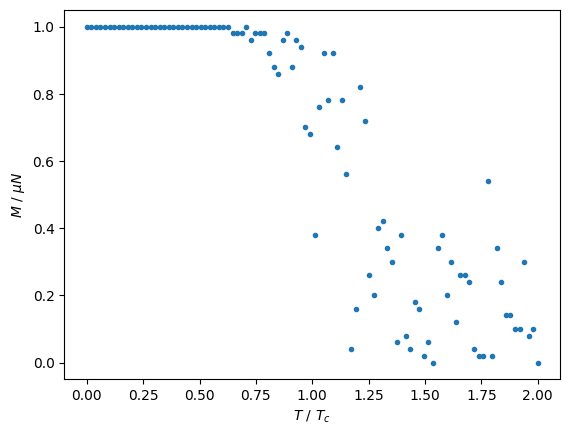

In [174]:
plt.plot(temp, m, '.')
plt.xlabel(r"$T \ / \ T_c$")
plt.ylabel(r"$M \ / \ \mu N$")
plt.savefig(f'mag_v_temp_{L}x{L}_{N}_iter')

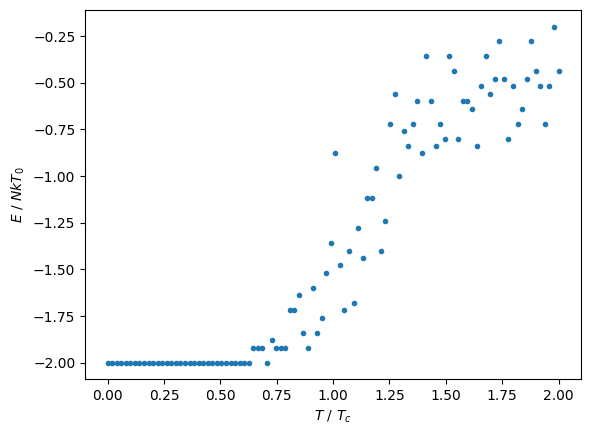

In [175]:
plt.plot(temp, E, '.')
plt.xlabel(r"$T \ / \ T_c$")
plt.ylabel(r"$E \ / \ NkT_0 $")
plt.savefig(f'energy_v_temp_{L}x{L}_{N}_iter')

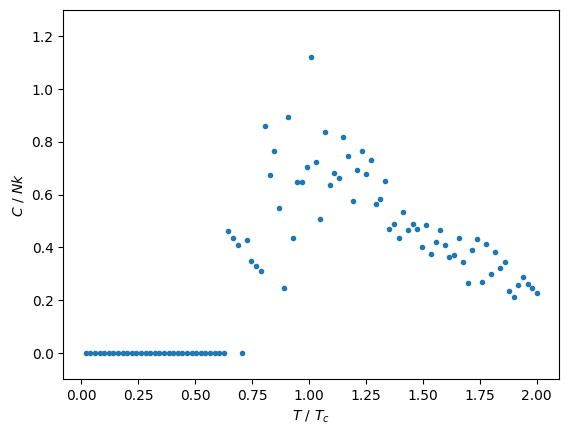

In [177]:
plt.plot(temp, C, '.')
plt.xlabel(r"$T \ / \ T_c$")
plt.ylabel(r"$C \ / \ Nk$")
plt.ylim(-0.1, 1.3)
plt.savefig(f'spec_heat_v_temp_{L}x{L}_{N}_iter')

These plots are ok. But they do not look as good as those from [Richard Fitzpatrick](https://farside.ph.utexas.edu/teaching/329/lectures/node110.html). I suspect that this is due to how I walk through the lattice. I am not doing it randomly but rather walking forward through each site. This effects the probability of going from a certain state in the system to another, as it makes a forward flip more probable than a reverse flip. I will try to use a random selection of the lattice and flip that site. 

Another likely problem is that I am not properly Monte Carlo sampling my observables. I should be taking measurements of the observables each time I take a snapshot and then take the mean of these samples to get a measurement.

I am going to rewrite my algorithm using some ideas from [Computing in Physics (Phy446)](https://courses.physics.illinois.edu/PHYS446/sp2023/Ising/IsingModel.html).

In [ ]:
def mcmc_random_walk(lattice, T, num_iter=100, output=True):
    height, width = lattice.shape
    snapshots = []
    snapshots.append(to_two_color(lattice))
    for iter in range(num_iter):
        
        if (iter % 5 == 0):
            snapshots.append(to_two_color(lattice))
            
        for i in range(height):
            for j in range(width):
                dH = calculate_dH(lattice, (i, j))
                if dH <= 0: # If energy decreases we accept the flip
                    lattice[i,j] = - lattice[i, j]
                elif rng.random() < np.exp(-dH/T): # If energy increases, we accept the flip with probability of Boltzmann distribution
                    lattice[i,j] = - lattice[i, j]

        M = lattice.sum() / lattice.size
        if output==True:
            print(f'Iteration {iter+1} complete. Net magnetization: {M} \n')
    
    return snapshots, lattice

In [ ]:
np.random.choice([1, -1], (5, 5))

array([[ 1,  1,  1, -1,  1],
       [-1, -1,  1, -1,  1],
       [-1, -1, -1, -1, -1],
       [ 1,  1, -1,  1, -1],
       [-1, -1,  1,  1, -1]])

In [120]:
def get_energy(spins):
    height, width = spins.shape
    energies = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            nn_sum = 0
            for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
                ii = (i + di) % height 
                jj = (j + dj) % width
                nn_sum += spins[ii, jj]
            energy = - (1 / 2) * spins[i, j] * nn_sum
            energies[i, j] = energy
    total_energy = energies.sum()
    return total_energy

In [63]:
def deltaE(spins, spin_to_flip):
    i, j = spin_to_flip
    height, width = spins.shape
    nn_sum = 0
    for di, dj in ((1, 0), (0, 1), (-1, 0), (0, -1)):
        ii = (i + di) % height 
        jj = (j + dj) % width
        nn_sum += spins[ii, jj]
    return 2 * spins[i, j] * nn_sum
    

Testing the deltaE function.

In [31]:
L = 3
spins =  np.random.choice([1, -1], (L, L))
spins

array([[-1, -1,  1],
       [-1,  1,  1],
       [-1,  1,  1]])

In [32]:
deltaE(spins, (0,0))

np.int64(4)

In [33]:
energy_before_flip = energy(spins)
spins[0,0] = - spins[0,0]
energy_after_flip = energy(spins)
energy_after_flip-energy_before_flip

np.float64(4.0)

We get the same result using `energy` and `deltaE` functions to determine the difference in energy after a single flip.

Now write a Monte Carlo Markov Chain algorithm that randomly selects a spin in the lattice and tries to flip it. We want to randomly select the spin so that the probability of transitioning from a configuration $c$ to another configuration $c'$ is the same as transitioning from $c'$ to $c$. That is $T(c\rightarrow c') = T(c'\rightarrow c)$. Following from detail balance, this ensures that the acceptance ratio
$$
\alpha \equiv {\pi(c')}/{\pi(c)}\cdot{T(c'\rightarrow c)}/{T(c\rightarrow c')} = {\pi(c')}/{\pi(c)}
$$
In other words the acceptance ratio is just the relative probability of the configurations $c$ and $c'$ occurring. The probability of configurations in our system is just the Boltzmann distribution.

We will also define a sweep as doing $N$ steps of the Metropolis Algorithm. We will take sample measurements at the end of these sweeps. This ensures that we wait long enough for the system to reach equilibrium and for the Markov Chain to forget the initial condition. 

In [175]:

def ising_mcmc(L, betaJ, N, num_sweeps=10000):
    spins =  np.random.choice([1, -1], (L, L))
    energy_measurements = []
    mag_sq_measurements = []
    snapshots = []

    for sweep in range(0, num_sweeps):
        for step in range(0, N):
            height, width = spins.shape
            randi = np.random.randint(0, height)
            randj = np.random.randint(0, width)
            dE = deltaE(spins, (randi, randj))
            if dE < 0:
                spins[randi, randj] = - spins[randi, randj]
            elif np.random.random() < np.exp(- dE * betaJ): 
                spins[randi, randj] = - spins[randi, randj]
        
        # measure
        energy_measurements.append(get_energy(spins))
        mag_sq = (spins.sum() / spins.size) ** 2
        mag_sq_measurements.append(mag_sq)
        # specific_heat
        snapshots.append(spins)#to_two_color(spins))
    
    return snapshots, energy_measurements, mag_sq_measurements

In [78]:
num_sweeps = 10000
N = 100
L = 10
betaJ = 0.5

snapshots, energies, mags = ising_mcmc(L, betaJ, N, num_sweeps=10000)

In [79]:
filename = (f'ising2_{betaJ}_{L}x{L}_{num_sweeps}_{N}.gif')
write_gif(snapshots, filename, fps=8)

Let us check the trend of the energies produced, to make sure we are at thermal equilibrium and not considering transient data.

Text(0, 0.5, 'Energy $E$')

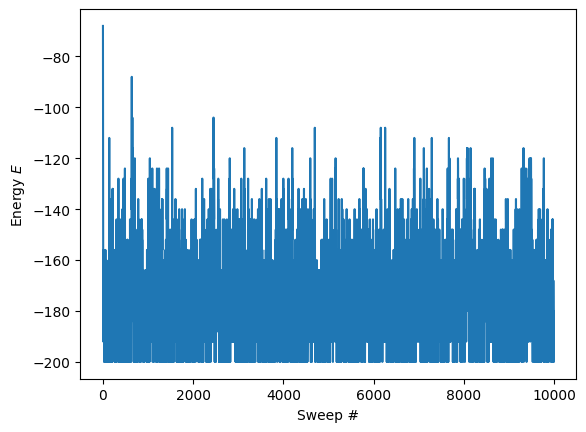

In [91]:
plt.plot(energies)
plt.xlabel('Sweep #')
plt.ylabel(r'Energy $E$')

Look at a histogram of the energy measurements and determine the mean and standard error.

Text(0, 0.5, 'Frequency')

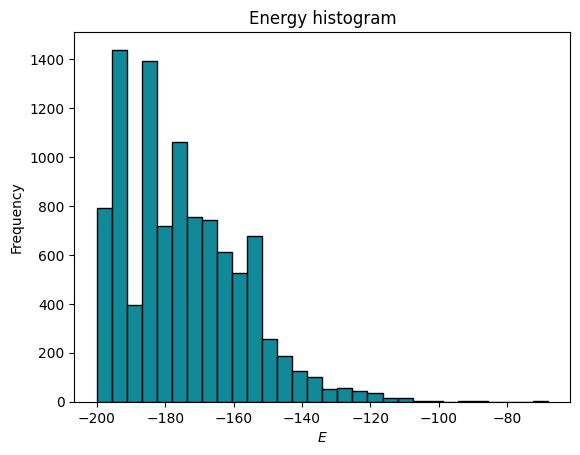

In [93]:
plt.hist(energies, bins=30, color='#108A99', edgecolor="black")
plt.title("Energy histogram")
plt.xlabel(r"$E$")
plt.ylabel("Frequency")

In [109]:
from scipy import stats
statistics = stats.describe(energies)
E_ave = statistics.mean
E_se = stats.sem(energies)
print(f"The average energy is {E_ave:0.3f} with a naive (assuming uncorrelated samples) standard error {E_se:0.3f}")


The average energy is -174.800 with a naive (assuming uncorrelated samples) standard error 0.171


The standard error of the mean above is assuming that we have uncorrelated samples. However, for a markov chain there is some correlation present in moving from one configuration to the next. We need to determine the integrated autocorrelation time $\tau$, the time (or number of steps) it takes for the samples to be uncorrelated or the time taken for the chain to forget where it started. We can then determine the effective sample size $N_{eff} = N/\tau$ and use this to calculate the standard error of the mean:
$$
\sigma_E = {\sigma}/{\sqrt{N_\text{eff}}} = \sqrt{{\text{Var}}/{N_\text{eff}}}
$$

There is a package `emcee` which calculates the auto correlation and integrated time for you. 

In [113]:
import emcee

tau = emcee.autocorr.integrated_time(energies)[0]
n_eff = len(energies) / tau
E_sem_corr = (statistics.variance / n_eff ) ** (1/2)

print(f"The integrated autocorrelation time is {tau:0.3f}, which gives effective sample size of {n_eff:0.3f}.")
print(f"The resulting correlated standard error in the mean is {E_sem_corr:0.3f}")

The integrated autocorrelation time is 8.976, which gives effective sample size of 1114.082.
The resulting correlated standard error in the mean is 0.511


Now we want to measure observables for a range of temperatures $\beta J \in [0, 1]$ and $\beta = \infty$. 
This will include calculating:
- Snapshots of the system
- A histogram of the the probability distribution
- The expectation value $< O >$ with the stadard error

First define functions for getting the histogram, snapshots and calculating the average value of an observable and its correlated standard error.

In [114]:
def measure_observable(observable_dist):
    statistics = stats.describe(observable_dist)
    average = statistics.mean
    tau = emcee.autocorr.integrated_time(observable_dist)[0]
    n_eff = len(observable_dist) / tau
    sem_corr = (statistics.variance / n_eff ) ** (1/2)
    return average, sem_corr

In [170]:
def get_hist(observable_dist, L, observable, betaJ, save_hist=True):
    fig, ax = plt.subplots()
    ax.hist(observable_dist, color="#24A2B3", edgecolor="black")
    ax.set_title(f"{observable} for betaJ = {betaJ:0.1f}")
    ax.set_xlabel("Values")
    ax.set_ylabel("Frequency")

    filename = f"./histograms/{L}x{L}_{observable}_betaJ_{betaJ:0.1f}.png"
    fig.savefig(filename, dpi=200)

    return fig

KeyboardInterrupt: 

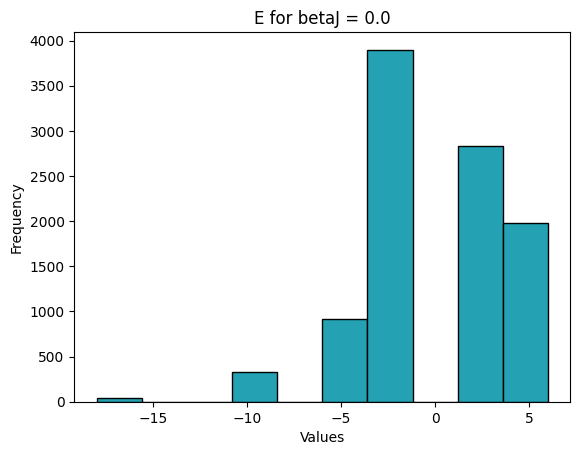

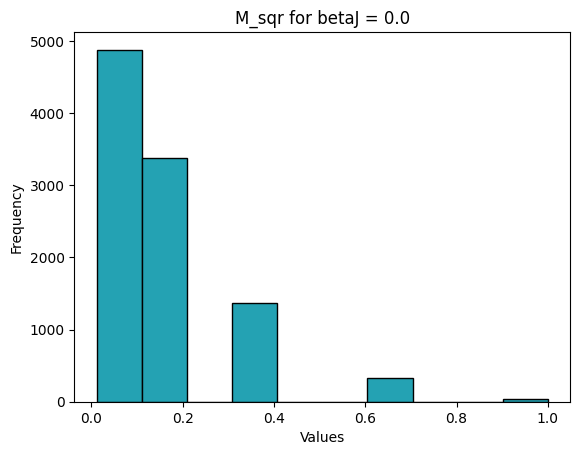

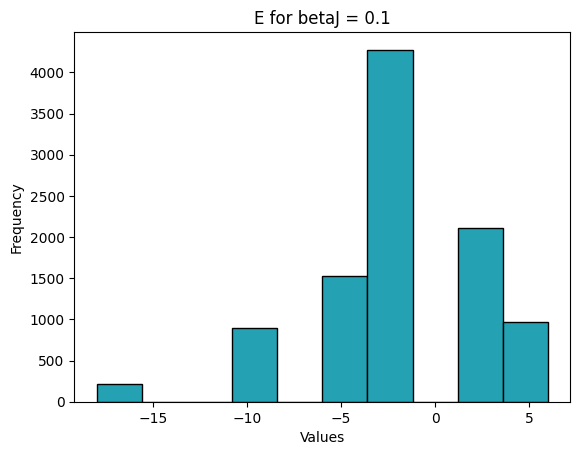

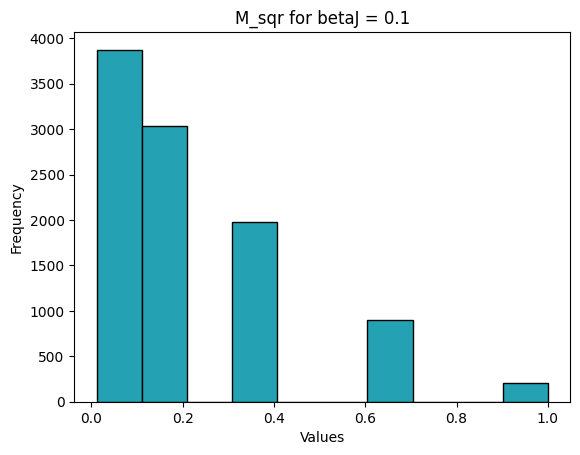

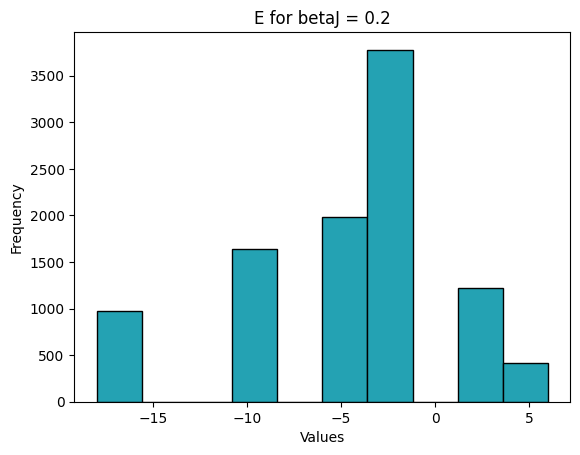

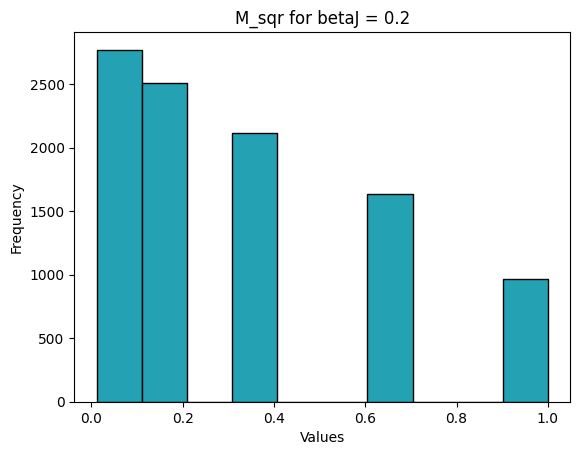

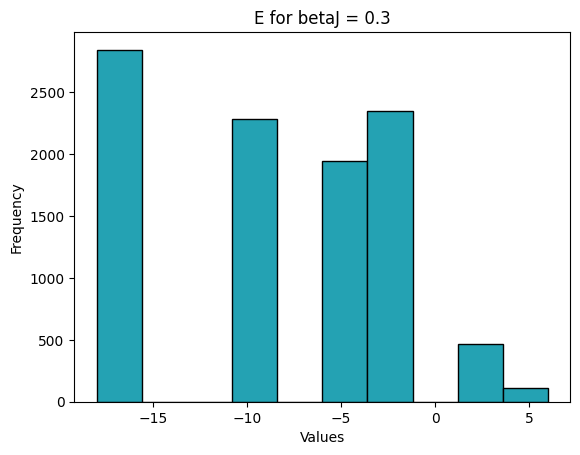

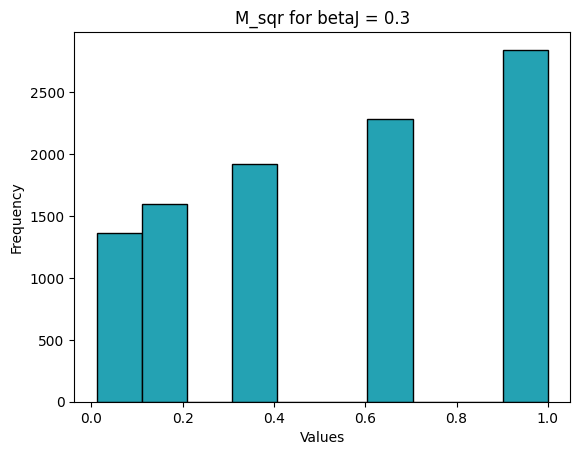

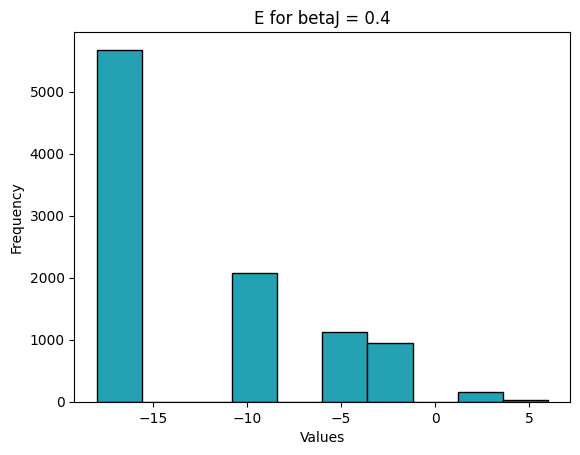

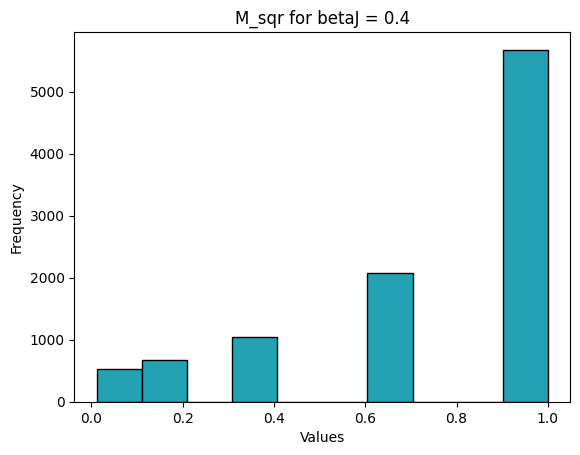

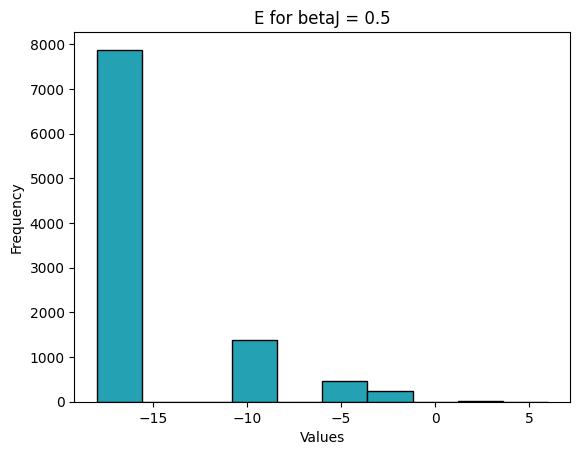

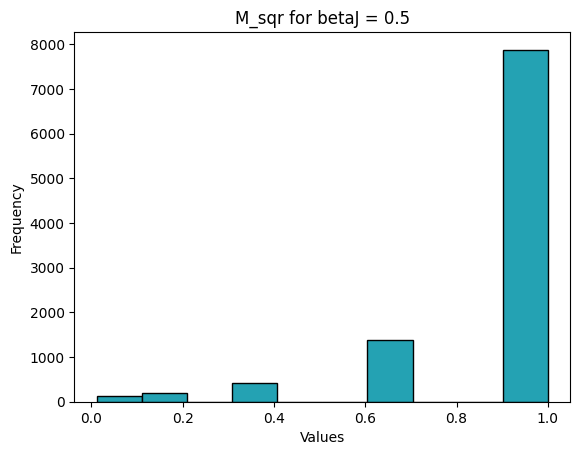

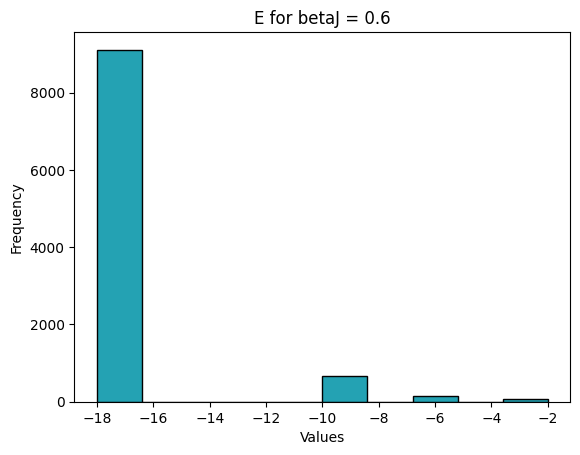

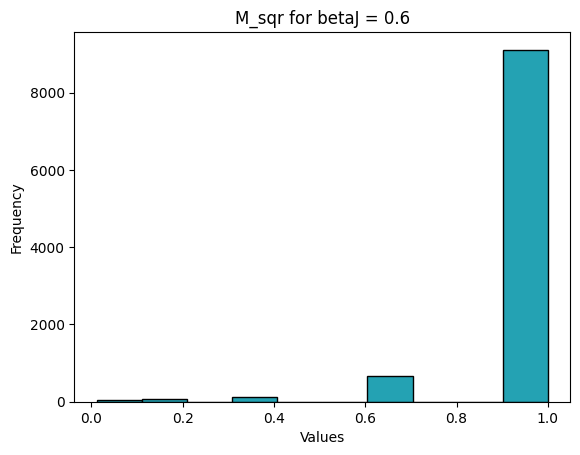

In [241]:
betaJ = np.linspace(0, 1, 11)
num_sweeps = 10000
N = 100
L = 3

energy = []
energy_err = []
magnetisation = []
magnetisation_err = []
final_snapshots = []
energy_hist_list = []
mag_hist_list = []

for bJ in betaJ:
    snapshots, energies, mags = ising_mcmc(L, bJ, N, num_sweeps)

    E, sigma_E = measure_observable(energies)
    m_sq, sigma_m_sq = measure_observable(mags)

    energy.append(E / (L**2)) # normalise energy
    energy_err.append(sigma_E)

    magnetisation.append(m_sq)
    magnetisation_err.append(sigma_m_sq)

    energy_hist_list.append(get_hist(energies, L, "E", bJ))
    mag_hist_list.append(get_hist(mags, L, "M_sqr", bJ))

    final_snapshots.append(snapshots[-1])


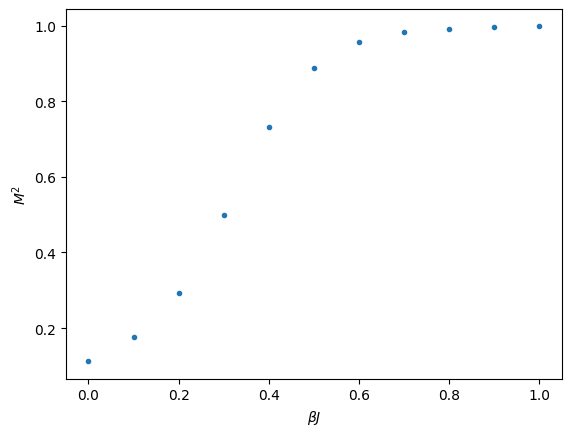

In [212]:
fig, ax = plt.subplots()
ax.errorbar(betaJ, magnetisation, yerr=magnetisation_err, fmt=".", ecolor='red')
ax.set_xlabel(r"$\beta J$")
ax.set_ylabel(r"$M^2$")
filename = f"./figures/ising_rand_M2_v_betaJ_{L}x{L}.png"
fig.savefig(filename)

Text(0, 0.5, '$E$')

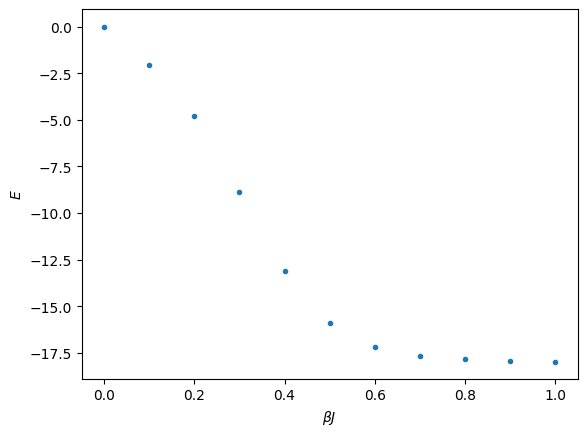

In [178]:
plt.errorbar(betaJ, energy, yerr=energy_err, fmt=".", ecolor='red')
plt.xlabel(r"$\beta J$")
plt.ylabel(r"$E$")

There is clearly a phase transition somewhere around $\beta J = 0.4$. To determine the critical temperature it is useful to calculate the specific heat $C = dE/dT$. We can calculate this multiple ways. One way is to use the thermodynamic relation:
$$
C = \sigma_E^2 / kT^2
$$
Recalling $T_0 = J/k$ we can rewrite this as
$$
C = \sigma_E^2 (1/kT)^2 k = \sigma_E^2 \beta^2 J / T_0 = \sigma_E^2 \beta^2 J^2 / (k T_0^2)
$$
so we have 
$$
C / (k T_0^2) = \sigma_E^2 (\beta J)^2
$$

Text(0, 0.5, '$C \\ (J^2/k)$')

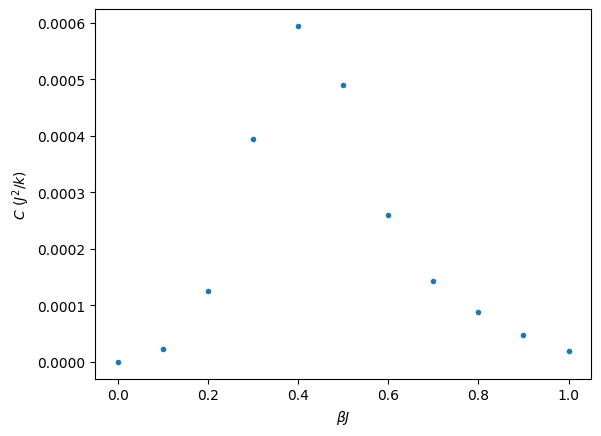

In [179]:
specific_heat = (energy_err * betaJ)**2
plt.plot(betaJ, specific_heat, '.')
plt.xlabel(r"$\beta J$")
plt.ylabel(r"$C \ (J^2/k)$")

Display the snapshots of the lattice for each temperature step.

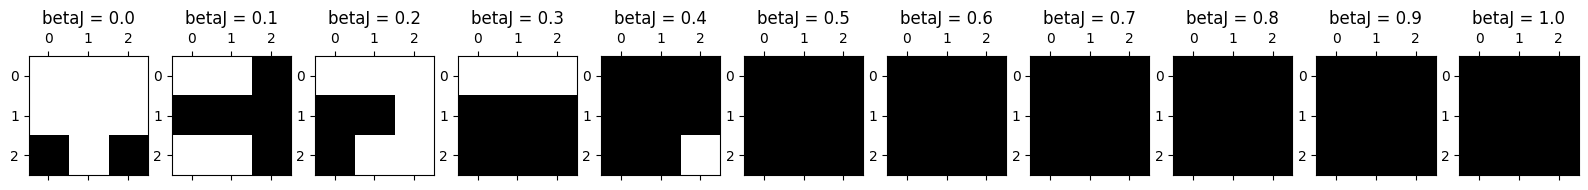

In [214]:
fig, ax = plt.subplots(1,len(final_snapshots), figsize=(20,10))
for i, snapshot in enumerate(final_snapshots):
    ax[i].matshow(snapshot, cmap='gray')
    ax[i].set_title(f'betaJ = {betaJ[i]:0.1f}')

In [247]:
def ising_betaJ_sweep(betaJ, L, N=100, num_sweeps=1000, plot_hist=False, plot_snapshots=False):

    energy = []
    energy_err = []
    magnetisation = []
    magnetisation_err = []
    final_snapshots = []
    energy_hist_list = []
    mag_hist_list = []

    if plot_snapshots == True:
        fig_snapshot, ax_snapshot = plt.subplots(1,len(betaJ), figsize=(20,10))

    for i, bJ in enumerate(betaJ):
        snapshots, energies, mags = ising_mcmc(L, bJ, N, num_sweeps)

        E, sigma_E = measure_observable(energies)
        m_sq, sigma_m_sq = measure_observable(mags)

        energy.append(E / (L**2)) # normalise energy
        energy_err.append(sigma_E / (L**2))

        magnetisation.append(m_sq)
        magnetisation_err.append(sigma_m_sq)

        if plot_hist==True:
            energy_hist_list.append(get_hist(energies, L, "E", bJ, ))
            mag_hist_list.append(get_hist(mags, L, "M_sqr", bJ))

        if plot_snapshots == True:
            final_snapshots.append(snapshots[-1])
            ax_snapshot[i].matshow(snapshots[-1], cmap='gray')
            ax_snapshot[i].set_title(f'betaJ = {bJ:0.1f}')

    if plot_snapshots == True:
        snapshot_filename = f"./figures/ising_rand_snapshots_v_betaJ_{L}x{L}.png"
        fig_snapshot.savefig(snapshot_filename, dpi=200)

    fig, ax = plt.subplots()
    ax.errorbar(betaJ, magnetisation, yerr=magnetisation_err, fmt=".", ecolor='red')
    ax.set_xlabel(r"$\beta J$")
    ax.set_ylabel(r"$M^2 / (\mu N)^2$")
    filename = f"./figures/ising_rand_M2_v_betaJ_{L}x{L}.png"
    fig.savefig(filename)

    fig, ax = plt.subplots()
    ax.errorbar(betaJ, energy, yerr=energy_err, fmt=".", ecolor='red')
    ax.set_xlabel(r"$\beta J$")
    ax.set_ylabel(r"$E / (NkT_0)$")
    filename = f"./figures/ising_rand_E_v_betaJ_{L}x{L}.png"
    fig.savefig(filename)

    specific_heat = (energy_err * betaJ)**2
    fig, ax = plt.subplots()
    ax.plot(betaJ, specific_heat, '.')
    ax.set_xlabel(r"$\beta J$")
    ax.set_ylabel(r"$C / (NkT_0^2)$")
    filename = f"./figures/ising_rand_C_v_betaJ_{L}x{L}.png"
    fig.savefig(filename)


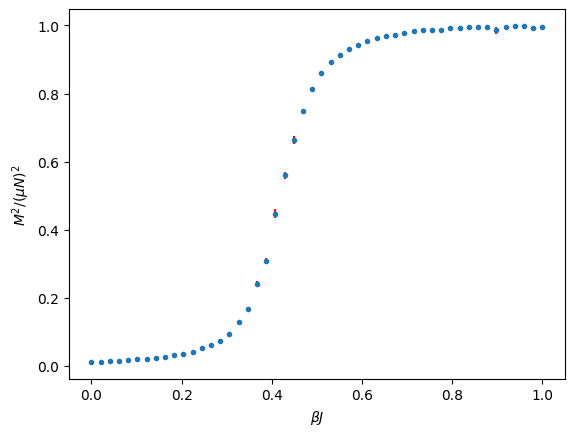

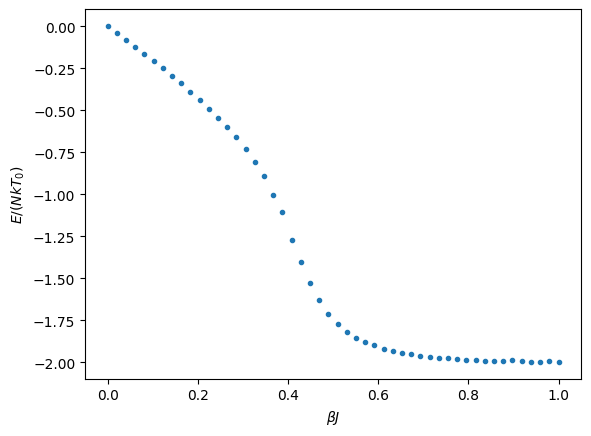

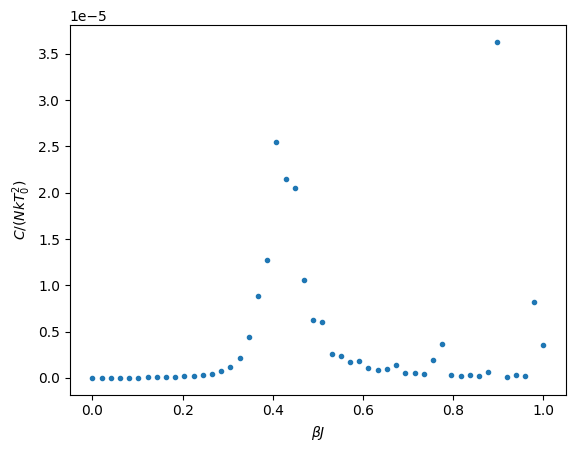

In [248]:
betaJ = np.linspace(0, 1, 50)
ising_betaJ_sweep(betaJ, L=9, N=100, num_sweeps=10000, plot_hist=False, plot_snapshots=False)

/var/folders/5w/_g0j34k53zndpmjg4_917wp80000gp/T/ipykernel_98308/214033667.py:1: RuntimeWarning: divide by zero encountered in divide
  1/betaJ


array([        inf, 19.        ,  9.5       ,  6.33333333,  4.75      ,
        3.8       ,  3.16666667,  2.71428571,  2.375     ,  2.11111111,
        1.9       ,  1.72727273,  1.58333333,  1.46153846,  1.35714286,
        1.26666667,  1.1875    ,  1.11764706,  1.05555556,  1.        ])